# FLORES-200 Model Benchmarks

Benchmark local NMT checkpoints against FLORES-200 English-Telugu devtest from the official repository.

This notebook reports translation quality and speed metrics for each checkpoint:
- BLEU (higher is better)
- chrF (higher is better)
- TER (lower is better)
- average seconds per sentence
- sentences per second

In [23]:
# Step 1: Import Dependencies
import json
import math
import time
from pathlib import Path

import pandas as pd
import requests
import sacrebleu
import sentencepiece as spm
import torch
import torch.nn as nn


def select_device():
    """Pick CUDA only if it is actually usable on this system."""
    if not torch.cuda.is_available():
        return torch.device("cpu")

    try:
        _ = torch.tensor([1.0], device="cuda") * 2.0
        torch.cuda.synchronize()
        return torch.device("cuda")
    except Exception as err:
        print(f"Warning: CUDA detected but unusable ({err}). Falling back to CPU.")
        return torch.device("cpu")


DEVICE = select_device()
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU model: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU.")

CUDA kernel errors might be asynchronously reported at some other API call,so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.). Falling back to CPU.
Using device: cpu
Running on CPU.


In [24]:
# Step 2: Configure Paths and Model Settings

# Define project structure and folders for caching data and models
ROOT = Path('.')
CACHE_DIR = ROOT / 'cache'
CKPT_DIR = CACHE_DIR / 'checkpoints'
FLORES_DIR = CACHE_DIR / 'flores200'
FLORES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Cache folder: {CACHE_DIR}")
print(f"Checkpoints folder: {CKPT_DIR}")

# Define core model parameters
VOCAB_SIZE = 32000          # Size of the vocabulary
MAX_SEQ_LEN = 128           # Maximum sentence length
PAD_ID = 0                  # Padding token ID
UNK_ID = 1                  # Unknown word token ID
BOS_ID = 2                  # Beginning-of-sentence token ID
EOS_ID = 3                  # End-of-sentence token ID

# Set path to the SentencePiece tokenizer model
TOKENIZER_PATH = CACHE_DIR / f'nmt_unigram_v1_{VOCAB_SIZE}.model'

# Match model configs from nmt_multi_size_final copy.ipynb
MODEL_CONFIGS = {
    '10M': {'d_model': 256, 'nhead': 4, 'num_enc_layers': 3, 'num_dec_layers': 3, 'd_ff': 1024, 'dropout': 0.10},
    '30M': {'d_model': 512, 'nhead': 8, 'num_enc_layers': 4, 'num_dec_layers': 4, 'd_ff': 2048, 'dropout': 0.10},
    '50M': {'d_model': 512, 'nhead': 8, 'num_enc_layers': 6, 'num_dec_layers': 6, 'd_ff': 2304, 'dropout': 0.10},
    '60M': {'d_model': 640, 'nhead': 8, 'num_enc_layers': 6, 'num_dec_layers': 6, 'd_ff': 2560, 'dropout': 0.12},
}

# Map model sizes to their checkpoint files
CHECKPOINTS = {
    '10M': CKPT_DIR / 'final_10m_model.pt',
    '30M': CKPT_DIR / 'final_30m_model.pt',
    '50M': CKPT_DIR / 'final_50m_model.pt',
    '60M': CKPT_DIR / 'final_60m_model.pt',
}

# Verify that the tokenizer model exists
if not TOKENIZER_PATH.exists():
    raise FileNotFoundError(f"Tokenizer not found at: {TOKENIZER_PATH}")

# Load the tokenizer
sp = spm.SentencePieceProcessor(model_file=str(TOKENIZER_PATH))
print("Tokenizer loaded successfully.")

Cache folder: cache
Checkpoints folder: cache/checkpoints
Tokenizer loaded successfully.


### Step 3: Define Model Architecture and Loading Utilities

This section sets up the Transformer model and a small set of helper functions for loading checkpoints safely.

Design goals:
- Keep the model code easy to read.
- Handle small checkpoint naming differences.
- Print clear warnings when keys do not match.

In [25]:
# Step 3: Model definition and loading helpers
import tarfile


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 1024, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, : x.size(1)])


class EncoderStack(nn.Module):
    def __init__(self, d_model: int, nhead: int, d_ff: int, num_layers: int, dropout: float):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, x: torch.Tensor, src_key_padding_mask: torch.Tensor) -> torch.Tensor:
        return self.encoder(x, src_key_padding_mask=src_key_padding_mask)


class DecoderStack(nn.Module):
    def __init__(self, d_model: int, nhead: int, d_ff: int, num_layers: int, dropout: float):
        super().__init__()
        layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_layers)

    def forward(
        self,
        tgt: torch.Tensor,
        memory: torch.Tensor,
        tgt_mask: torch.Tensor,
        tgt_key_padding_mask: torch.Tensor,
        memory_key_padding_mask: torch.Tensor,
    ) -> torch.Tensor:
        return self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )


class NMTTrans(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        nhead: int,
        num_enc_layers: int,
        num_dec_layers: int,
        d_ff: int,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.d_model = d_model
        self.scale = math.sqrt(d_model)

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.position = PositionalEncoding(d_model=d_model, max_len=MAX_SEQ_LEN, dropout=dropout)
        self.encoder = EncoderStack(d_model=d_model, nhead=nhead, d_ff=d_ff, num_layers=num_enc_layers, dropout=dropout)
        self.decoder = DecoderStack(d_model=d_model, nhead=nhead, d_ff=d_ff, num_layers=num_dec_layers, dropout=dropout)

        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.embedding.weight

        self._init_weights()

    def _init_weights(self) -> None:
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        src_pad_mask = src.eq(PAD_ID)
        tgt_pad_mask = tgt.eq(PAD_ID)

        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)

        src_emb = self.position(self.embedding(src) * self.scale)
        tgt_emb = self.position(self.embedding(tgt) * self.scale)

        memory = self.encoder(src_emb, src_key_padding_mask=src_pad_mask)
        decoded = self.decoder(
            tgt=tgt_emb,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )
        return self.lm_head(decoded)


def load_checkpoint(path):
    """Load checkpoint safely across torch versions."""
    print(f"  Loading checkpoint: {path}")
    try:
        ckpt = torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        ckpt = torch.load(path, map_location=DEVICE)
    return ckpt


def normalize_state_dict_keys(state_dict):
    """Handle common key variations across saved checkpoints."""
    normalized = {}
    for key, value in state_dict.items():
        new_key = key.replace('module.', '')
        new_key = new_key.replace('pos_enc.', 'position.')
        new_key = new_key.replace('output_proj.', 'lm_head.')
        new_key = new_key.replace('encoder.encoder.', 'encoder.encoder.')
        new_key = new_key.replace('decoder.decoder.', 'decoder.decoder.')
        normalized[new_key] = value
    return normalized


def load_model(model_name):
    """Build NMTTrans from config and load checkpoint weights."""
    checkpoint_path = CHECKPOINTS[model_name]
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    ckpt = load_checkpoint(checkpoint_path)
    config = ckpt.get('config', MODEL_CONFIGS[model_name]) if isinstance(ckpt, dict) else MODEL_CONFIGS[model_name]

    model = NMTTrans(vocab_size=VOCAB_SIZE, **config).to(DEVICE)

    weights = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
    weights = normalize_state_dict_keys(weights)

    missing_keys, unexpected_keys = model.load_state_dict(weights, strict=False)
    if missing_keys:
        print(f"  Warning: Missing {len(missing_keys)} tensors (default init used).")
    if unexpected_keys:
        print(f"  Warning: Ignoring {len(unexpected_keys)} unexpected tensors.")

    model.eval()
    print(f"Model {model_name} loaded.")
    return model

### Step 4: Define Decoding Function

The function below performs greedy decoding for fast and deterministic inference during benchmarking.

In [26]:
@torch.inference_mode()
def greedy_decode(model, src_text, max_len=100):
    """Translate one English sentence to Telugu using greedy decoding."""
    input_ids = [BOS_ID] + sp.encode(src_text)[:MAX_SEQ_LEN - 2] + [EOS_ID]
    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=DEVICE)

    src_pad_mask = input_tensor.eq(PAD_ID)
    src_emb = model.position(model.embedding(input_tensor) * model.scale)
    memory = model.encoder(src_emb, src_key_padding_mask=src_pad_mask)

    output_ids = [BOS_ID]
    for _ in range(max_len):
        output_tensor = torch.tensor([output_ids], dtype=torch.long, device=DEVICE)
        tgt_emb = model.position(model.embedding(output_tensor) * model.scale)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(len(output_ids)).to(DEVICE)

        decoder_out = model.decoder(
            tgt=tgt_emb,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=output_tensor.eq(PAD_ID),
            memory_key_padding_mask=src_pad_mask,
        )

        logits = model.lm_head(decoder_out[:, -1, :])
        next_id = int(logits.argmax(dim=-1).item())

        if next_id == EOS_ID:
            break
        output_ids.append(next_id)

    return sp.decode(output_ids[1:])

### Step 5: Download and Validate FLORES-200 Data

This step downloads English source and Telugu reference files (with fallback extraction from archive), then validates aligned pairs.

In [27]:
print('=' * 72)
print('Loading FLORES-200 Translation Test Data')
print('=' * 72)


def download_text_file(candidate_urls, output_path):
    """Try downloading from candidate URLs until one succeeds."""
    for url in candidate_urls:
        try:
            print(f"  Trying URL: {url}")
            response = requests.get(url, timeout=30)
            if response.status_code == 200 and response.text.strip():
                output_path.write_text(response.text, encoding='utf-8')
                print('  Download successful.')
                return True
        except Exception as err:
            print(f"  Failed: {err}")
    return False


def ensure_from_tarball(output_path, language_code):
    """Fallback: download FLORES archive and extract requested language file."""
    archive_path = FLORES_DIR / 'flores200_dataset.tar.gz'

    if not archive_path.exists():
        print('\n  Downloading FLORES archive...')
        response = requests.get('https://tinyurl.com/flores200dataset', timeout=120)
        response.raise_for_status()
        archive_path.write_bytes(response.content)
        print('  Archive downloaded.')

    print(f"  Extracting {language_code} from archive...")
    with tarfile.open(archive_path, 'r:gz') as tar:
        for member in tar.getmembers():
            if member.isfile() and language_code in member.name and 'devtest' in member.name:
                extracted = tar.extractfile(member)
                if extracted is None:
                    continue
                output_path.write_bytes(extracted.read())
                print('  Extraction successful.')
                return True

    return False


eng_file = FLORES_DIR / 'eng_Latn.devtest'
tel_file = FLORES_DIR / 'tel_Telu.devtest'

if not eng_file.exists():
    print('\nDownloading English source data...')
    success = download_text_file(
        [
            'https://raw.githubusercontent.com/facebookresearch/flores/main/flores200_dataset/devtest/eng_Latn.devtest',
            'https://raw.githubusercontent.com/facebookresearch/flores/main/flores200_dataset/devtest/devtest.eng_Latn',
        ],
        eng_file,
    )
    if not success:
        if not ensure_from_tarball(eng_file, 'eng_Latn'):
            raise RuntimeError('Unable to prepare English source file.')
else:
    print('English source data already exists.')

if not tel_file.exists():
    print('\nDownloading Telugu reference data...')
    success = download_text_file(
        [
            'https://raw.githubusercontent.com/facebookresearch/flores/main/flores200_dataset/devtest/tel_Telu.devtest',
            'https://raw.githubusercontent.com/facebookresearch/flores/main/flores200_dataset/devtest/devtest.tel_Telu',
        ],
        tel_file,
    )
    if not success:
        if not ensure_from_tarball(tel_file, 'tel_Telu'):
            raise RuntimeError('Unable to prepare Telugu reference file.')
else:
    print('Telugu reference data already exists.')

print('\nReading data files...')
sources = [line.strip() for line in eng_file.read_text(encoding='utf-8').splitlines() if line.strip()]
references = [line.strip() for line in tel_file.read_text(encoding='utf-8').splitlines() if line.strip()]

if len(sources) != len(references):
    raise ValueError(f"Data mismatch: English={len(sources)}, Telugu={len(references)}")

print(f"Loaded {len(sources)} aligned translation pairs.")

Loading FLORES-200 Translation Test Data
English source data already exists.
Telugu reference data already exists.

Reading data files...
Loaded 1012 aligned translation pairs.


### Step 6: Run Model Benchmarks

Each checkpoint is loaded, translated on the full FLORES-200 devtest set, and evaluated using BLEU, chrF, and TER.

In [28]:
def benchmark_model(model_name, model, src_texts, ref_texts):
    """Run full-set inference and compute translation quality + speed metrics."""
    print(f"\nTranslating {len(src_texts)} sentences with {model_name}...")

    predictions = []
    start_time = time.perf_counter()

    for idx, english_text in enumerate(src_texts, start=1):
        predictions.append(greedy_decode(model, english_text))
        if idx % 50 == 0:
            print(f"  Progress: {idx}/{len(src_texts)}")

    elapsed = time.perf_counter() - start_time

    print(f"Computing metrics for {model_name}...")
    refs = [ref_texts]
    bleu = sacrebleu.corpus_bleu(predictions, refs).score
    chrf = sacrebleu.corpus_chrf(predictions, refs).score
    ter = sacrebleu.corpus_ter(predictions, refs).score

    return {
        'Model': model_name,
        'Samples': len(src_texts),
        'BLEU': round(bleu, 4),
        'chrF': round(chrf, 4),
        'TER': round(ter, 4),
        'Total Time (sec)': round(elapsed, 2),
        'Sec/Sentence': round(elapsed / len(src_texts), 4),
        'Sentences/Sec': round(len(src_texts) / elapsed, 2),
    }, predictions


def is_cuda_runtime_issue(err):
    text = str(err).lower()
    return (
        'no kernel image is available' in text
        or 'cuda error' in text
        or 'device-side assert triggered' in text
    )


all_results = []
all_predictions = {}

for model_size in ['10M', '30M', '50M', '60M']:
    checkpoint_path = CHECKPOINTS[model_size]
    if not checkpoint_path.exists():
        print(f"\nWarning: Skipping {model_size} (checkpoint missing).")
        continue

    print(f"\n{'-' * 72}")
    print(f"Benchmarking model: {model_size}")
    print(f"{'-' * 72}")

    model = load_model(model_size)

    try:
        result, predictions = benchmark_model(model_size, model, sources, references)
    except RuntimeError as err:
        if DEVICE.type == 'cuda' and is_cuda_runtime_issue(err):
            print("\nCUDA runtime issue detected. Retrying this model on CPU...")
            globals()['DEVICE'] = torch.device('cpu')
            model = load_model(model_size)
            result, predictions = benchmark_model(model_size, model, sources, references)
        else:
            raise

    all_results.append(result)
    all_predictions[model_size] = predictions

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


------------------------------------------------------------------------
Benchmarking model: 10M
------------------------------------------------------------------------
  Loading checkpoint: cache/checkpoints/final_10m_model.pt


Model 10M loaded.

Translating 1012 sentences with 10M...
  Progress: 50/1012
  Progress: 100/1012
  Progress: 150/1012
  Progress: 200/1012
  Progress: 250/1012
  Progress: 300/1012
  Progress: 350/1012
  Progress: 400/1012
  Progress: 450/1012
  Progress: 500/1012
  Progress: 550/1012
  Progress: 600/1012
  Progress: 650/1012
  Progress: 700/1012
  Progress: 750/1012
  Progress: 800/1012
  Progress: 850/1012
  Progress: 900/1012
  Progress: 950/1012
  Progress: 1000/1012
Computing metrics for 10M...

------------------------------------------------------------------------
Benchmarking model: 30M
------------------------------------------------------------------------
  Loading checkpoint: cache/checkpoints/final_30m_model.pt
Model 30M loaded.

Translating 1012 sentences with 30M...
  Progress: 50/1012
  Progress: 100/1012
  Progress: 150/1012
  Progress: 200/1012
  Progress: 250/1012
  Progress: 300/1012
  Progress: 350/1012
  Progress: 400/1012
  Progress: 450/1012
  Progress: 500/1

KeyboardInterrupt: 

### Step 7: Display and Save Results

This section creates a leaderboard table and writes both CSV and JSON outputs for later analysis.

In [ ]:
if not all_results:
    raise RuntimeError('No benchmark results were generated. Check checkpoint availability.')

results_table = pd.DataFrame(all_results).sort_values('BLEU', ascending=False).reset_index(drop=True)

print(f"\n{'=' * 72}")
print('FINAL BENCHMARK RESULTS')
print(f"{'=' * 72}\n")
print(results_table.to_string(index=False))
print('\nMetric guide: higher BLEU/chrF is better, lower TER is better.')

csv_file = CKPT_DIR / 'flores200_benchmark_results.csv'
json_file = CKPT_DIR / 'flores200_benchmark_results.json'

results_table.to_csv(csv_file, index=False)
json_file.write_text(json.dumps([dict(row) for row in all_results], indent=2), encoding='utf-8')

print(f"\nSaved CSV results to: {csv_file}")
print(f"Saved JSON results to: {json_file}")


FINAL BENCHMARK RESULTS

Model  Samples     BLEU     chrF      TER  Total Time (sec)  Sec/Sentence  Sentences/Sec
  60M     1012  14.9917  48.9043  74.7137            165.81        0.1638           6.10
  50M     1012  14.8847  48.9692  73.4266            136.10        0.1345           7.44
  30M     1012  13.9961  47.7346  75.7764             91.63        0.0905          11.04
  10M     1012  11.0221  43.5609  79.6906             38.61        0.0382          26.21

Metric guide: higher BLEU/chrF is better, lower TER is better.

Saved CSV results to: cache/checkpoints/flores200_benchmark_results.csv
Saved JSON results to: cache/checkpoints/flores200_benchmark_results.json


### Step 8: Qualitative Examples from the Best Model

Metrics are useful, but examples make the behavior easier to understand. This section shows a few sample translations from the best-BLEU model so you can quickly see what it gets right and where it struggles.

In [ ]:
best_model_name = results_table.iloc[0]['Model']
best_predictions = all_predictions[best_model_name]

print(f"\n{'=' * 72}")
print(f"EXAMPLE TRANSLATIONS FROM BEST MODEL: {best_model_name}")
print(f"{'=' * 72}\n")

for example_idx in range(min(5, len(sources))):
    print(f"Example {example_idx + 1}")
    print(f"  EN : {sources[example_idx]}")
    print(f"  REF: {references[example_idx]}")
    print(f"  HYP: {best_predictions[example_idx]}")
    print('-' * 72)


EXAMPLE TRANSLATIONS FROM BEST MODEL: 60M

Example 1
  EN : "We now have 4-month-old mice that are non-diabetic that used to be diabetic," he added.
  REF: """""""ఇప్పుడు మావద్ద 4 నెలల వయస్సు గల ఎలుకలు ఉన్నాయి, అవి మధుమేహం లేనివి, అవి మధుమేహవ్యాధిగా ఉన్నాయి,"""" అని ఆయన అన్నారు."""
  HYP: ఇప్పుడు మనకు 4 నెలల పాప ఉంది, ఇది డయాబెటిక్ కానిది, ఇది మధుమేహ వ్యాధిగ్రస్తుల మని ఆయన అన్నారు.
------------------------------------------------------------------------
Example 2
  EN : Dr. Ehud Ur, professor of medicine at Dalhousie University in Halifax, Nova Scotia and chair of the clinical and scientific division of the Canadian Diabetes Association cautioned that the research is still in its early days.
  REF: హాలిఫాక్స్, నోవా స్కోటియాలోని డల్హౌసీ విశ్వవిద్యాలయంలో మెడిసిన్ ప్రొఫెసర్ డాక్టర్ ఎహుద్ మీ ఇంకా కెనడియన్ డయాబెటిస్ అసోసియేషన్ యొక్క క్లినికల్ సైంటిఫిక్ విభాగానికి చెందిన డాక్టర్ ఎహుద్ మీ, పరిశోధన ఇంకా ప్రారంభ రోజుల్లో ఉందని హెచ్చరించారు.
  HYP: హాలిఫాక్స్ లోని డాల్హౌసీ విశ్వవిద్యాలయంలో వైద్

### Step 9: Greedy vs Beam Search Comparison

This final section compares greedy decoding with beam search for every model size. The goal is to see whether beam search improves translation quality enough to justify the extra decoding time.

In [ ]:
BEAM_SIZE = 4
BEAM_LENGTH_PENALTY = 0.7


@torch.inference_mode()
def beam_search_decode(model, src_text, beam_size=BEAM_SIZE, max_len=100, length_penalty=BEAM_LENGTH_PENALTY):
    """Translate one sentence using beam search."""
    input_ids = [BOS_ID] + sp.encode(src_text)[:MAX_SEQ_LEN - 2] + [EOS_ID]
    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=DEVICE)

    src_pad_mask = input_tensor.eq(PAD_ID)
    src_emb = model.position(model.embedding(input_tensor) * model.scale)
    memory = model.encoder(src_emb, src_key_padding_mask=src_pad_mask)

    beams = [([BOS_ID], 0.0)]
    completed = []

    for _ in range(max_len):
        candidates = []

        for tokens, score in beams:
            if tokens[-1] == EOS_ID:
                completed.append((tokens, score))
                candidates.append((tokens, score))
                continue

            tgt_tensor = torch.tensor([tokens], dtype=torch.long, device=DEVICE)
            tgt_emb = model.position(model.embedding(tgt_tensor) * model.scale)
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(len(tokens)).to(DEVICE)

            decoder_out = model.decoder(
                tgt=tgt_emb,
                memory=memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=tgt_tensor.eq(PAD_ID),
                memory_key_padding_mask=src_pad_mask,
            )

            logits = model.lm_head(decoder_out[:, -1, :])
            log_probs = torch.log_softmax(logits, dim=-1)
            top_log_probs, top_ids = torch.topk(log_probs, beam_size, dim=-1)

            for log_prob, token_id in zip(top_log_probs[0].tolist(), top_ids[0].tolist()):
                candidates.append((tokens + [int(token_id)], score + float(log_prob)))

        if not candidates:
            break

        def normalized_score(item):
            tokens, score = item
            token_count = max(len(tokens) - 1, 1)
            return score / (token_count ** length_penalty)

        candidates.sort(key=normalized_score, reverse=True)
        beams = candidates[:beam_size]

        if all(tokens[-1] == EOS_ID for tokens, _ in beams):
            completed.extend(beams)
            break

    final_pool = completed if completed else beams
    best_tokens, _ = max(final_pool, key=lambda item: item[1] / (max(len(item[0]) - 1, 1) ** length_penalty))
    return sp.decode(best_tokens[1:-1] if best_tokens and best_tokens[-1] == EOS_ID else best_tokens[1:])


@torch.inference_mode()
def benchmark_decoding_strategy(model_name, model, src_texts, ref_texts, decode_fn, strategy_name):
    """Benchmark one decoding strategy and compute corpus metrics."""
    print(f"\nTranslating {len(src_texts)} sentences with {model_name} using {strategy_name}...")

    predictions = []
    start_time = time.perf_counter()

    for idx, english_text in enumerate(src_texts, start=1):
        predictions.append(decode_fn(model, english_text))
        if idx % 50 == 0:
            print(f"  Progress: {idx}/{len(src_texts)}")

    elapsed = time.perf_counter() - start_time
    refs = [ref_texts]

    bleu = sacrebleu.corpus_bleu(predictions, refs).score
    chrf = sacrebleu.corpus_chrf(predictions, refs).score
    ter = sacrebleu.corpus_ter(predictions, refs).score

    return {
        'Model': model_name,
        'Strategy': strategy_name,
        'Samples': len(src_texts),
        'BLEU': round(bleu, 4),
        'chrF': round(chrf, 4),
        'TER': round(ter, 4),
        'Total Time (sec)': round(elapsed, 2),
        'Sec/Sentence': round(elapsed / len(src_texts), 4),
        'Sentences/Sec': round(len(src_texts) / elapsed, 2),
    }, predictions


comparison_rows = []
comparison_predictions = {}

print(f"\n{'=' * 72}")
print(f"GREEDY VS BEAM SEARCH COMPARISON (beam size = {BEAM_SIZE})")
print(f"{'=' * 72}")

for model_size in ['10M', '30M', '50M', '60M']:
    checkpoint_path = CHECKPOINTS[model_size]
    if not checkpoint_path.exists():
        print(f"\nWarning: Skipping {model_size} (checkpoint missing).")
        continue

    print(f"\n{'-' * 72}")
    print(f"Comparing decoding strategies for {model_size}")
    print(f"{'-' * 72}")

    model = load_model(model_size)

    greedy_result, greedy_preds = benchmark_decoding_strategy(
        model_size,
        model,
        sources,
        references,
        greedy_decode,
        'Greedy',
    )
    beam_result, beam_preds = benchmark_decoding_strategy(
        model_size,
        model,
        sources,
        references,
        beam_search_decode,
        f'Beam-{BEAM_SIZE}',
    )

    comparison_rows.extend([greedy_result, beam_result])
    comparison_predictions[model_size] = {
        'Greedy': greedy_preds,
        f'Beam-{BEAM_SIZE}': beam_preds,
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

comparison_df = pd.DataFrame(comparison_rows)
comparison_pivot = comparison_df.pivot(index='Model', columns='Strategy')
comparison_summary = pd.DataFrame({
    'Greedy BLEU': comparison_pivot['BLEU']['Greedy'],
    f'Beam-{BEAM_SIZE} BLEU': comparison_pivot['BLEU'][f'Beam-{BEAM_SIZE}'],
    'BLEU Delta': comparison_pivot['BLEU'][f'Beam-{BEAM_SIZE}'] - comparison_pivot['BLEU']['Greedy'],
    'Greedy chrF': comparison_pivot['chrF']['Greedy'],
    f'Beam-{BEAM_SIZE} chrF': comparison_pivot['chrF'][f'Beam-{BEAM_SIZE}'],
    'chrF Delta': comparison_pivot['chrF'][f'Beam-{BEAM_SIZE}'] - comparison_pivot['chrF']['Greedy'],
    'Greedy TER': comparison_pivot['TER']['Greedy'],
    f'Beam-{BEAM_SIZE} TER': comparison_pivot['TER'][f'Beam-{BEAM_SIZE}'],
    'TER Delta': comparison_pivot['TER'][f'Beam-{BEAM_SIZE}'] - comparison_pivot['TER']['Greedy'],
    'Greedy Sec/Sentence': comparison_pivot['Sec/Sentence']['Greedy'],
    f'Beam-{BEAM_SIZE} Sec/Sentence': comparison_pivot['Sec/Sentence'][f'Beam-{BEAM_SIZE}'],
}).reset_index()

print(f"\n{'=' * 72}")
print('GREEDY VS BEAM SUMMARY')
print(f"{'=' * 72}\n")
print(comparison_summary.to_string(index=False))

comparison_csv = CKPT_DIR / 'greedy_vs_beam_comparison.csv'
comparison_json = CKPT_DIR / 'greedy_vs_beam_comparison.json'
comparison_df.to_csv(comparison_csv, index=False)
comparison_json.write_text(json.dumps([dict(row) for row in comparison_rows], indent=2), encoding='utf-8')

print(f"\nSaved comparison CSV to: {comparison_csv}")
print(f"Saved comparison JSON to: {comparison_json}")


GREEDY VS BEAM SEARCH COMPARISON (beam size = 4)

------------------------------------------------------------------------
Comparing decoding strategies for 10M
------------------------------------------------------------------------
  Loading checkpoint: cache/checkpoints/final_10m_model.pt
Model 10M loaded.

Translating 1012 sentences with 10M using Greedy...
  Progress: 50/1012
  Progress: 100/1012
  Progress: 150/1012
  Progress: 200/1012
  Progress: 250/1012
  Progress: 300/1012
  Progress: 350/1012
  Progress: 400/1012
  Progress: 450/1012
  Progress: 500/1012
  Progress: 550/1012
  Progress: 600/1012


### Step 10: Greedy vs Beam Search Visualizations

This section generates publication-ready graphs for:
- Translation quality (BLEU, chrF, TER)
- Decoding speed (throughput and slowdown)
- Normalized quality radar per model

Loaded comparison data from: cache/checkpoints/greedy_vs_beam_comparison.csv


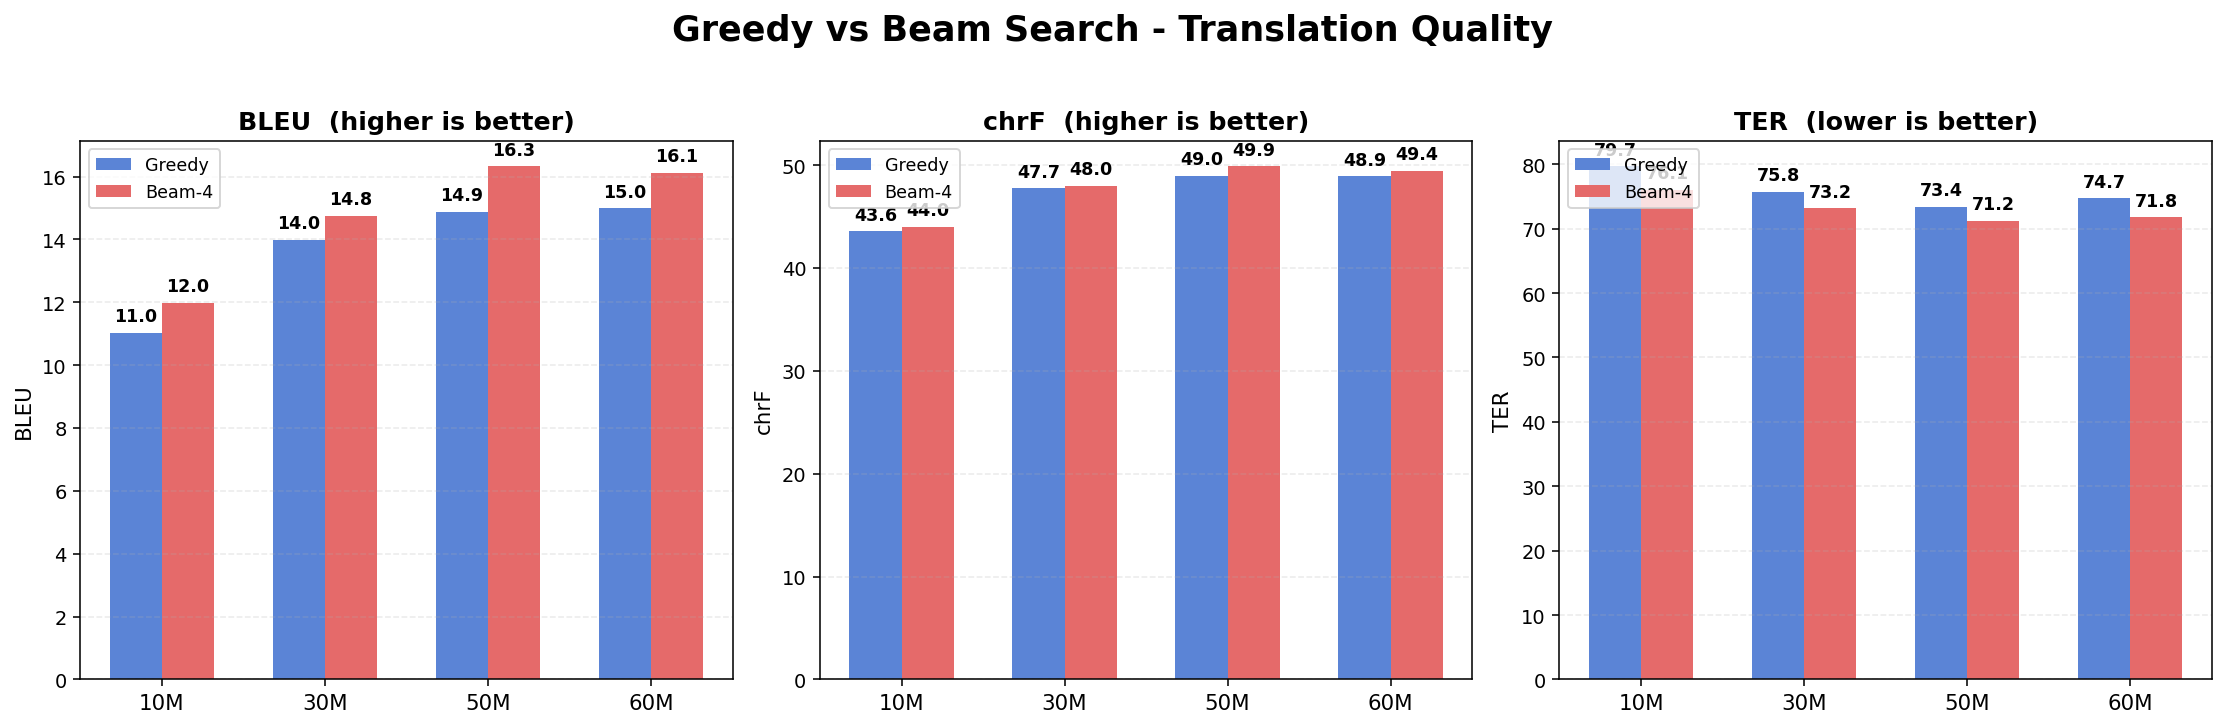

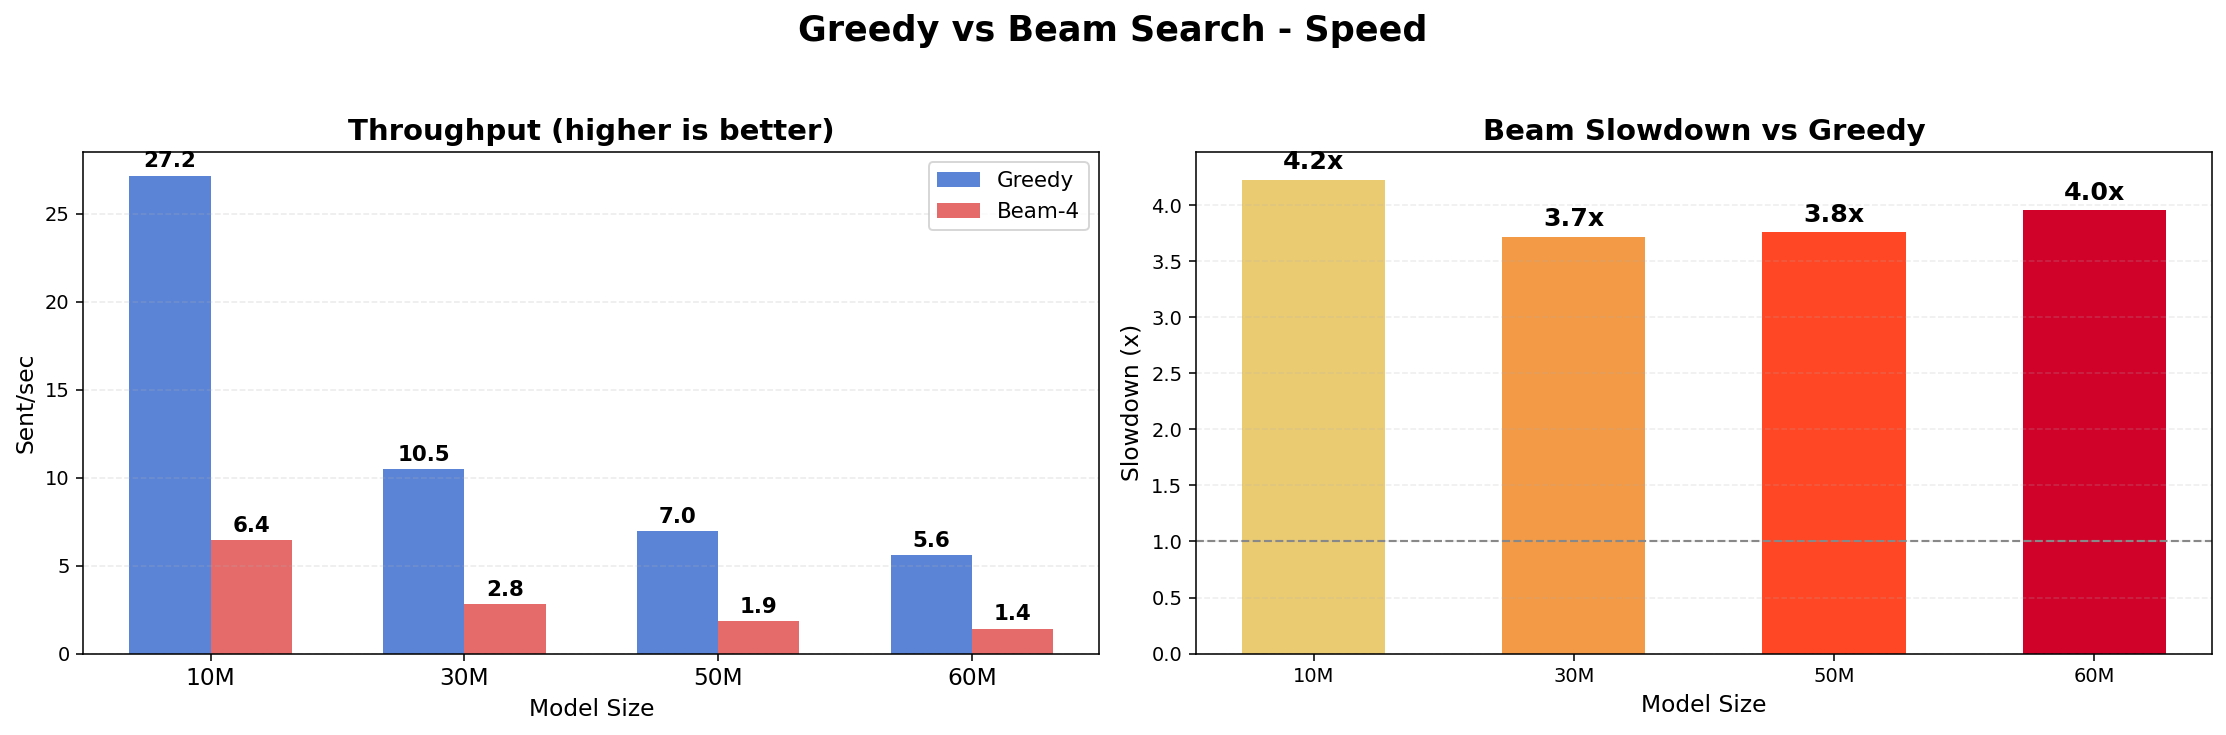

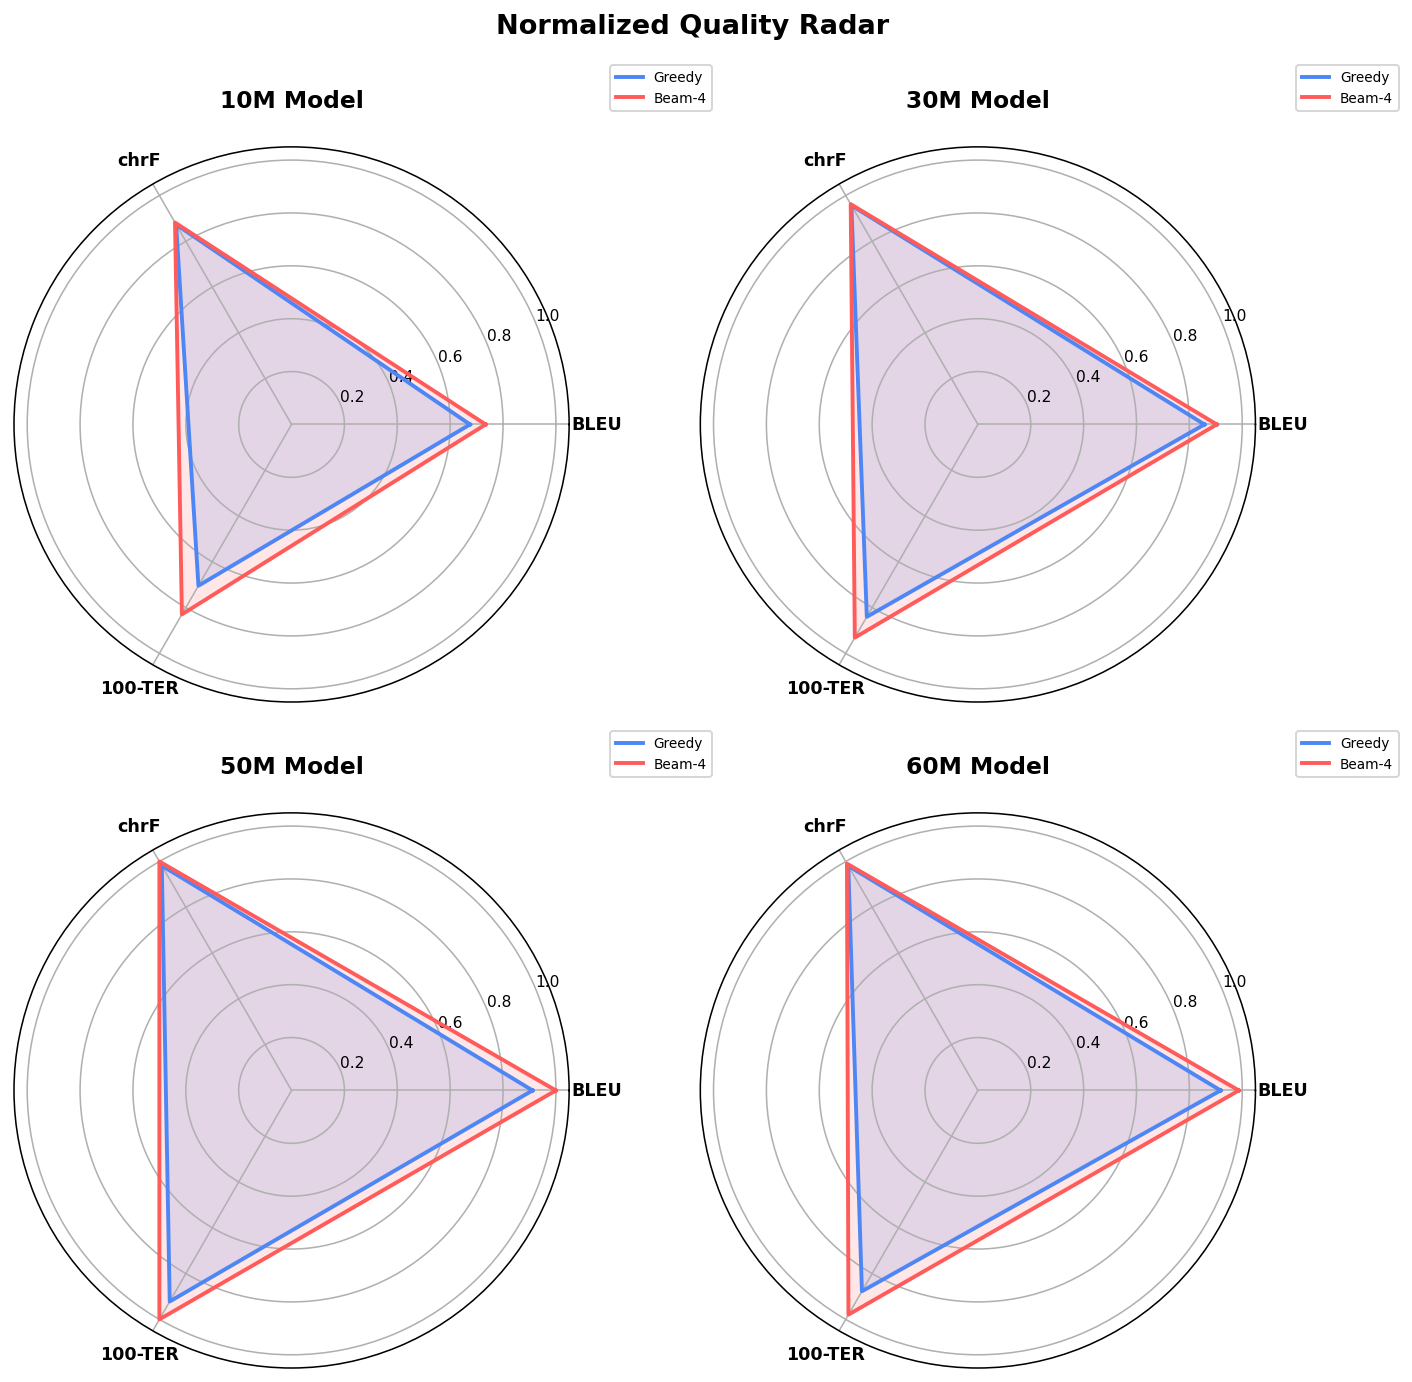

Saved plot files:
- cache/checkpoints/greedy_vs_beam_quality.png
- cache/checkpoints/greedy_vs_beam_speed.png
- cache/checkpoints/greedy_vs_beam_radar.png


In [ ]:
# Step 10: Plot Greedy vs Beam graphs
import numpy as np
import matplotlib.pyplot as plt

# Use in-memory comparison_df if available; otherwise load from saved CSV.
if "comparison_df" not in globals() or comparison_df is None or len(comparison_df) == 0:
    comparison_csv_fallback = CKPT_DIR / "greedy_vs_beam_comparison.csv"
    if not comparison_csv_fallback.exists():
        raise RuntimeError(
            "Greedy vs Beam results are not available. Run Step 9 first."
        )
    comparison_df = pd.read_csv(comparison_csv_fallback)
    print(f"Loaded comparison data from: {comparison_csv_fallback}")

# Resolve beam strategy label dynamically.
if "BEAM_SIZE" in globals():
    beam_label = f"Beam-{BEAM_SIZE}"
else:
    beam_candidates = [
        s for s in comparison_df["Strategy"].astype(str).unique() if s.startswith("Beam-")
    ]
    if not beam_candidates:
        raise RuntimeError("No beam-search strategy found in comparison_df.")
    beam_label = sorted(beam_candidates)[0]


greedy_df = comparison_df[comparison_df["Strategy"] == "Greedy"].set_index("Model")
beam_df = comparison_df[comparison_df["Strategy"] == beam_label].set_index("Model")

preferred_order = ["10M", "30M", "50M", "60M"]
models = [m for m in preferred_order if m in greedy_df.index and m in beam_df.index]
if not models:
    models = sorted(set(greedy_df.index).intersection(set(beam_df.index)))
if not models:
    raise RuntimeError("No common models found between Greedy and Beam results.")

greedy_df = greedy_df.loc[models]
beam_df = beam_df.loc[models]

quality_plot_path = CKPT_DIR / "greedy_vs_beam_quality.png"
speed_plot_path = CKPT_DIR / "greedy_vs_beam_speed.png"
radar_plot_path = CKPT_DIR / "greedy_vs_beam_radar.png"


# -----------------------------
# Figure 1: Translation Quality
# -----------------------------
x = np.arange(len(models))
bar_width = 0.32

fig_q, axes_q = plt.subplots(1, 3, figsize=(16, 5), dpi=140)
metric_specs = [
    ("BLEU", "BLEU", "BLEU  (higher is better)"),
    ("chrF", "chrF", "chrF  (higher is better)"),
    ("TER", "TER", "TER  (lower is better)"),
]

for ax, (metric_key, y_label, title_text) in zip(axes_q, metric_specs):
    greedy_vals = greedy_df[metric_key].astype(float).values
    beam_vals = beam_df[metric_key].astype(float).values

    bars_greedy = ax.bar(
        x - bar_width / 2,
        greedy_vals,
        width=bar_width,
        color="#5B84D6",
        label="Greedy",
    )
    bars_beam = ax.bar(
        x + bar_width / 2,
        beam_vals,
        width=bar_width,
        color="#E56A6A",
        label=beam_label,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(title_text, fontsize=13, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    y_top = max(float(np.max(greedy_vals)), float(np.max(beam_vals)), 1.0)
    y_offset = 0.015 * y_top

    for bars in (bars_greedy, bars_beam):
        for rect in bars:
            height = rect.get_height()
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                height + y_offset,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

    ax.legend(loc="upper left", fontsize=9)

fig_q.suptitle("Greedy vs Beam Search - Translation Quality", fontsize=18, fontweight="bold", y=1.03)
fig_q.tight_layout()
fig_q.savefig(quality_plot_path, dpi=160, bbox_inches="tight")
plt.show()


# ---------------------
# Figure 2: Speed Plots
# ---------------------
greedy_tps = greedy_df["Sentences/Sec"].astype(float).values
beam_tps = beam_df["Sentences/Sec"].astype(float).values
slowdown = beam_df["Sec/Sentence"].astype(float).values / np.maximum(
    greedy_df["Sec/Sentence"].astype(float).values,
    1e-12,
)

fig_s, axes_s = plt.subplots(1, 2, figsize=(16, 5), dpi=140)

bars_tps_g = axes_s[0].bar(x - bar_width / 2, greedy_tps, width=bar_width, color="#5B84D6", label="Greedy")
bars_tps_b = axes_s[0].bar(x + bar_width / 2, beam_tps, width=bar_width, color="#E56A6A", label=beam_label)
axes_s[0].set_title("Throughput (higher is better)", fontsize=15, fontweight="bold")
axes_s[0].set_ylabel("Sent/sec", fontsize=12)
axes_s[0].set_xlabel("Model Size", fontsize=12)
axes_s[0].set_xticks(x)
axes_s[0].set_xticklabels(models, fontsize=12)
axes_s[0].grid(axis="y", linestyle="--", alpha=0.25)
axes_s[0].legend(loc="upper right", fontsize=11)

for bars in (bars_tps_g, bars_tps_b):
    for rect in bars:
        value = rect.get_height()
        axes_s[0].text(
            rect.get_x() + rect.get_width() / 2,
            value + 0.25,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

slowdown_colors = ["#EACB72", "#F29A45", "#FF4625", "#D0022A"]
bars_slow = axes_s[1].bar(models, slowdown, color=slowdown_colors[:len(models)], width=0.55)
axes_s[1].axhline(1.0, color="#888888", linestyle="--", linewidth=1.1)
axes_s[1].set_title("Beam Slowdown vs Greedy", fontsize=15, fontweight="bold")
axes_s[1].set_ylabel("Slowdown (x)", fontsize=12)
axes_s[1].set_xlabel("Model Size", fontsize=12)
axes_s[1].set_ylim(0, max(4.4, float(np.max(slowdown)) + 0.25))
axes_s[1].grid(axis="y", linestyle="--", alpha=0.22)

for rect, value in zip(bars_slow, slowdown):
    axes_s[1].text(
        rect.get_x() + rect.get_width() / 2,
        value + 0.05,
        f"{value:.1f}x",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )

fig_s.suptitle("Greedy vs Beam Search - Speed", fontsize=18, fontweight="bold", y=1.04)
fig_s.tight_layout()
fig_s.savefig(speed_plot_path, dpi=160, bbox_inches="tight")
plt.show()


# ---------------------------
# Figure 3: Radar Comparison
# ---------------------------
bleu_scale = max(float(comparison_df["BLEU"].max()), 1e-9)
chrf_scale = max(float(comparison_df["chrF"].max()), 1e-9)
ter_inv_scale = max(float((100.0 - comparison_df["TER"]).max()), 1e-9)

radar_axes_labels = ["BLEU", "chrF", "100-TER"]
angles = np.linspace(0, 2 * np.pi, len(radar_axes_labels), endpoint=False).tolist()
angles += angles[:1]

fig_r, axes_r = plt.subplots(2, 2, subplot_kw={"polar": True}, figsize=(10, 10), dpi=140)
axes_r = axes_r.flatten()

for idx, model_name in enumerate(models):
    ax = axes_r[idx]

    greedy_profile = [
        float(greedy_df.loc[model_name, "BLEU"]) / bleu_scale,
        float(greedy_df.loc[model_name, "chrF"]) / chrf_scale,
        (100.0 - float(greedy_df.loc[model_name, "TER"])) / ter_inv_scale,
    ]
    beam_profile = [
        float(beam_df.loc[model_name, "BLEU"]) / bleu_scale,
        float(beam_df.loc[model_name, "chrF"]) / chrf_scale,
        (100.0 - float(beam_df.loc[model_name, "TER"])) / ter_inv_scale,
    ]

    greedy_profile += greedy_profile[:1]
    beam_profile += beam_profile[:1]

    ax.plot(angles, greedy_profile, color="#4E87F5", linewidth=2.0, label="Greedy")
    ax.fill(angles, greedy_profile, color="#4E87F5", alpha=0.18)
    ax.plot(angles, beam_profile, color="#FF5B5B", linewidth=2.0, label=beam_label)
    ax.fill(angles, beam_profile, color="#FF5B5B", alpha=0.14)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_axes_labels, fontsize=9, fontweight="bold")
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
    ax.set_ylim(0.0, 1.05)
    ax.set_title(f"{model_name} Model", y=1.05, fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.27, 1.16), fontsize=7)

for idx in range(len(models), len(axes_r)):
    axes_r[idx].set_axis_off()

fig_r.suptitle("Normalized Quality Radar", fontsize=14, fontweight="bold", y=0.99)
fig_r.tight_layout()
fig_r.savefig(radar_plot_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved plot files:")
print(f"- {quality_plot_path}")
print(f"- {speed_plot_path}")
print(f"- {radar_plot_path}")

### Step 11: Beam minus Greedy Delta Heatmap

This plot shows metric deltas per model as:
- $\Delta\text{BLEU} = \text{Beam} - \text{Greedy}$
- $\Delta\text{chrF} = \text{Beam} - \text{Greedy}$
- $\Delta\text{TER} = \text{Beam} - \text{Greedy}$

Color meaning matches the presentation style:
- Green shades: positive deltas
- Red shades: negative deltas

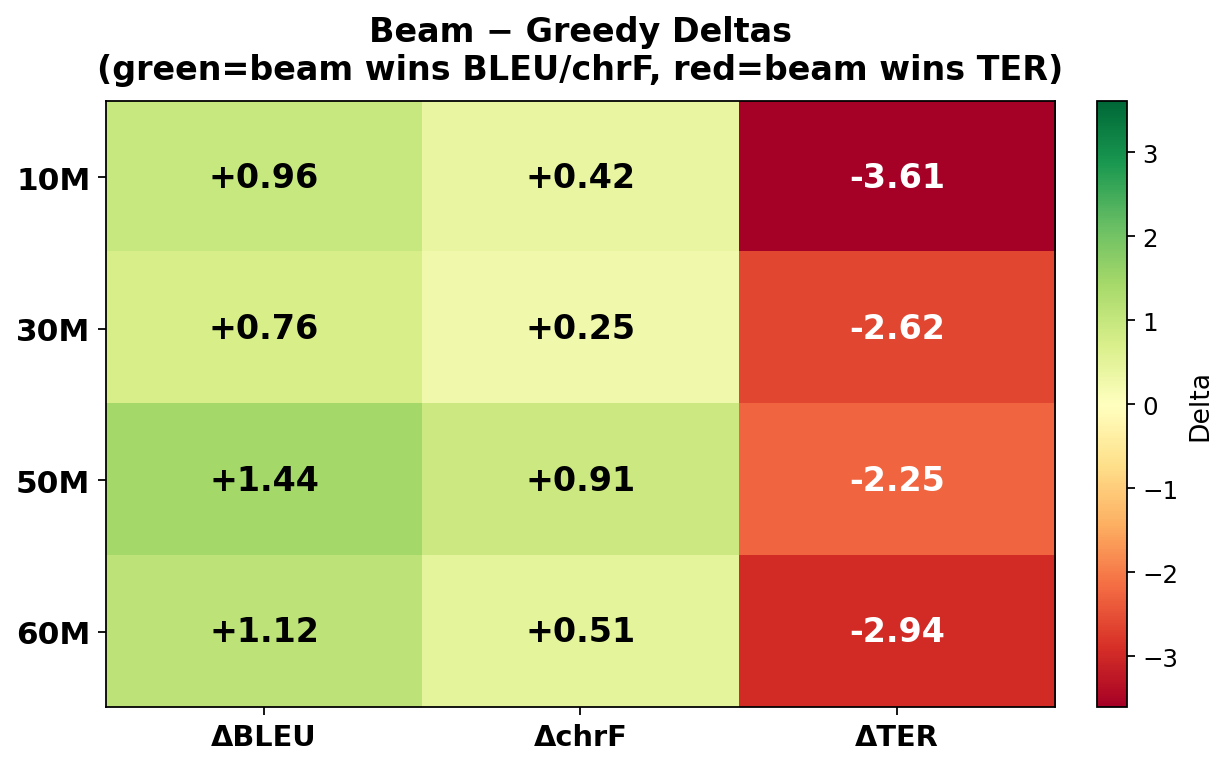

Saved delta heatmap to: cache/checkpoints/greedy_vs_beam_delta_heatmap.png


In [5]:
# Step 11: Delta heatmap (Beam - Greedy)
import numpy as np
import matplotlib.pyplot as plt

if "greedy_df" not in globals() or "beam_df" not in globals() or len(greedy_df) == 0:
    fallback_csv = CKPT_DIR / "greedy_vs_beam_comparison.csv"
    if not fallback_csv.exists():
        raise RuntimeError("Comparison data not found. Run Step 9 first.")

    temp_df = pd.read_csv(fallback_csv)
    beam_candidates = [
        strategy
        for strategy in temp_df["Strategy"].astype(str).unique()
        if strategy.startswith("Beam-")
    ]
    if not beam_candidates:
        raise RuntimeError("No beam strategy found in comparison CSV.")

    local_beam_label = beam_candidates[0]
    local_greedy_df = temp_df[temp_df["Strategy"] == "Greedy"].set_index("Model")
    local_beam_df = temp_df[temp_df["Strategy"] == local_beam_label].set_index("Model")
else:
    local_beam_label = beam_label if "beam_label" in globals() else "Beam"
    local_greedy_df = greedy_df.copy()
    local_beam_df = beam_df.copy()

model_order = ["10M", "30M", "50M", "60M"]
model_list = [m for m in model_order if m in local_greedy_df.index and m in local_beam_df.index]
if not model_list:
    model_list = sorted(set(local_greedy_df.index).intersection(set(local_beam_df.index)))
if not model_list:
    raise RuntimeError("No overlapping models found for heatmap plot.")

local_greedy_df = local_greedy_df.loc[model_list]
local_beam_df = local_beam_df.loc[model_list]

delta_matrix = np.column_stack([
    local_beam_df["BLEU"].astype(float).values - local_greedy_df["BLEU"].astype(float).values,
    local_beam_df["chrF"].astype(float).values - local_greedy_df["chrF"].astype(float).values,
    local_beam_df["TER"].astype(float).values - local_greedy_df["TER"].astype(float).values,
])

fig, ax = plt.subplots(figsize=(7.8, 4.9), dpi=160)
max_abs = max(float(np.abs(delta_matrix).max()), 1e-6)
im = ax.imshow(
    delta_matrix,
    cmap="RdYlGn",
    vmin=-max_abs,
    vmax=max_abs,
    aspect="auto",
)

ax.set_xticks(np.arange(3))
ax.set_xticklabels(["ΔBLEU", "ΔchrF", "ΔTER"], fontsize=13, fontweight="bold")
ax.set_yticks(np.arange(len(model_list)))
ax.set_yticklabels(model_list, fontsize=14, fontweight="bold")

for row in range(delta_matrix.shape[0]):
    for col in range(delta_matrix.shape[1]):
        value = float(delta_matrix[row, col])
        text_color = "white" if abs(value) >= 1.7 else "black"
        ax.text(
            col,
            row,
            f"{value:+.2f}",
            ha="center",
            va="center",
            fontsize=15,
            fontweight="bold",
            color=text_color,
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Delta", fontsize=12)
cbar.ax.tick_params(labelsize=11)

ax.set_title(
    "Beam − Greedy Deltas\n(green=beam wins BLEU/chrF, red=beam wins TER)",
    fontsize=15,
    fontweight="bold",
    pad=10,
)

heatmap_path = CKPT_DIR / "greedy_vs_beam_delta_heatmap.png"
fig.tight_layout()
fig.savefig(heatmap_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved delta heatmap to: {heatmap_path}")